In [64]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
from scipy.interpolate import RegularGridInterpolator

## Sailboat Speed Model 

### Purpose
Computes the effective sailboat speed within a single spatial grid cell by combining:
- Empirical polar performance (wind-driven speed with operational limits)
- Encounter-based wave effects (directional and speed-dependent)
- Bathymetric feasibility constraints based on sailboat draft

The model is designed for grid-based routing and path optimization.

---

## Inputs

### Environmental inputs
- **TWA**: True wind angle (deg)
- **TWS**: True wind speed (m/s)
- **Hs**: Significant wave height (m)
- **T**: Wave period (s)
- **wave_dir**: Wave propagation direction (deg)

### Navigation state
- **boat_heading**: Vessel course direction (deg)

### Bathymetry
- **depth**: Water depth (m)
- **draft**: Vessel draft (m)

### Model components
- **compute_Vs()**: Polar interpolation function with enforced sailing limits
- **data**: Polar dataset including:
  - TWA–TWS speed table
  - Interpolator
  - Beating and running limits (angle and speed envelopes)

### Constants
- **g**: gravitational acceleration (9.81 m/s²)
- **KNOT_TO_MS**: knot-to-m/s conversion factor

---

## Outputs

### Primary output
- **V_eff**: Effective sailboat speed (m/s)

### Diagnostics dictionary
Intermediate variables for debugging and analysis:
- `valid_depth`: Depth constraint status
- `V_polar`: Polar-based speed (after limits)
- `valid_wave`: Wave input validity
- `delta_theta`: Relative wave–boat angle (deg)
- `encounter_period`: Encounter-adjusted wave period (s)
- `wave_steepness_S`: Non-dimensional wave severity
- `P_wave`: Wave-induced reduction factor
- `V_eff`: Final effective speed

---

## Method Overview

### 1. Bathymetry constraint
- If **depth < draft** → vessel cannot pass  
- Output: `NaN`, `valid_depth = False`

---

### 2. Polar speed model (with sailing envelope)

Boat speed is computed using interpolated polar data with **hard physical sailing limits**:

- Function: `V_polar = compute_Vs(TWA, TWS, data)`

Key behaviors:
- **TWS bounds enforced** → outside range → speed = 0
- **Upwind/downwind limits enforced**:
  - Below beating angle → no progress
  - Above running angle → no progress
- **Boundary interpolation** ensures smooth transitions near limits
- Includes extrapolation toward beating/running performance curves

---

### 3. Relative wave direction

Wave influence depends on alignment:

- Δθ = relative_angle(wave_dir, boat_heading)

Interpretation:
- **0°** → following seas (lower resistance)
- **90°** → beam seas
- **180°** → head seas (highest resistance)

---

### 4. Wave encounter formulation (no currents)

Wave interaction is modeled using a Doppler-like encounter frequency shift:

- ω = 2π / T  
- ωₑ = ω · (1 − (V_ship / (gT)) · cos(Δθ))  
- T_enc = 2π / |ωₑ|

Where:
- V_ship ≈ V_polar (minimum threshold applied for stability)

---

### 5. Wave severity metric

Wave impact is expressed using an encounter-based steepness parameter:

- S = (2π Hs) / (g T_enc²)

Properties:
- Increases with wave height
- Increases for shorter encounter periods
- Decreases for long, gentle waves

---

### 6. Wave penalty function

A smooth, bounded reduction factor is applied:

- P_wave = 1 / (1 + S²)

Characteristics:
- Range: [0, 1]
- Monotonic decay with increasing wave severity
- Numerically stable across all regimes

---

### 7. Final effective speed

- **V_eff = V_polar × P_wave**

---

## Key Assumptions

- No ocean currents
- Locally homogeneous wave field per grid cell
- Vessel speed governed by polar performance only
- Wave effects applied multiplicatively (no force balance)
- Depth acts as a feasibility constraint only
- Linear wave superposition in encounter formulation

---

## Strengths

- Incorporates realistic sailing limits (beating/running constraints)
- Physically grounded encounter-period formulation
- No empirical tuning parameters required
- Stable across low and high wave energy regimes
- Efficient for large spatial grids

---

## Limitations

- No explicit hydrodynamic resistance or drag model
- No wave–current interaction
- No vessel dynamics (pitch, heave, surfing)
- Simplified Doppler approximation
- No directional spreading of wave energy

---

## Intended Use

- Grid-based sailing route optimization
- VMG and travel-time estimation in spatially varying conditions
- Coupling with environmental datasets (wind, waves, bathymetry)

In [65]:

KNOT_TO_MS = 0.51444
g = 9.81


# =========================================================
# HELPERS
# =========================================================
def to_numeric_array(arr):
    return pd.to_numeric(arr, errors="coerce").to_numpy(dtype=float)


def relative_angle(a, b):
    angle = abs(a - b) % 360
    return angle if angle <= 180 else 360 - angle


# =========================================================
# POLAR DATA LOADING
# =========================================================
def load_polar_data(polar_csv, rb_csv):
    df = pd.read_csv(polar_csv, header=None, dtype=str, skip_blank_lines=False)

    TWS_knots = to_numeric_array(df.iloc[0, 2:])
    TWS_ms = TWS_knots * KNOT_TO_MS

    TWA = to_numeric_array(df.iloc[4:15, 1])

    Vs_table = (
        df.iloc[4:15, 2:2 + len(TWS_ms)]
        .apply(pd.to_numeric, errors="coerce")
        .to_numpy(dtype=float) * KNOT_TO_MS
    )

    interp_polar = RegularGridInterpolator(
        (TWA, TWS_ms),
        Vs_table,
        bounds_error=False,
        fill_value=None
    )

    df_rb = pd.read_csv(rb_csv, header=None, dtype=str, skip_blank_lines=False)
    df_rb_num = df_rb.iloc[:, 1:].apply(pd.to_numeric, errors="coerce")

    TWS_rb_knots = to_numeric_array(df_rb.iloc[1, 2:])
    TWS_rb = TWS_rb_knots * KNOT_TO_MS

    beating_TWA, beating_Vs = [], []
    running_TWA, running_Vs = [], []

    for i, row in enumerate(df_rb.itertuples(index=False)):
        label = str(row[0])
        TWA_val = df_rb_num.iloc[i, 0]

        if np.isnan(TWA_val):
            continue

        values = df_rb_num.iloc[i, 1:].to_numpy(dtype=float)
        valid_idx = np.where(~np.isnan(values))[0]

        if len(valid_idx) == 0:
            continue

        j = valid_idx[0]
        tws = TWS_rb[j]
        Vs_val = values[j] * KNOT_TO_MS

        if "Beating" in label:
            beating_TWA.append((tws, TWA_val))
            beating_Vs.append((tws, Vs_val))

        elif "Running" in label:
            running_TWA.append((tws, TWA_val))
            running_Vs.append((tws, Vs_val))

    return {
        "TWS": TWS_ms,
        "TWA": TWA,
        "interp_polar": interp_polar,
        "beating_TWA": np.array(beating_TWA),
        "beating_Vs": np.array(beating_Vs),
        "running_TWA": np.array(running_TWA),
        "running_Vs": np.array(running_Vs),
    }


# =========================================================
# POLAR SPEED
# =========================================================
def compute_Vs(TWA_input, TWS_input, data):
    TWS = data["TWS"]
    TWA = data["TWA"]
    interp_polar = data["interp_polar"]

    beating_TWA = data["beating_TWA"]
    beating_Vs = data["beating_Vs"]
    running_TWA = data["running_TWA"]
    running_Vs = data["running_Vs"]

    # --- HARD TWS CUT ---
    if TWS_input < TWS[0] or TWS_input > TWS[-1]:
        return 0.0

    # --- INTERPOLATE LIMITS ---
    TWA_beat = np.interp(TWS_input, beating_TWA[:, 0], beating_TWA[:, 1])
    TWA_run = np.interp(TWS_input, running_TWA[:, 0], running_TWA[:, 1])

    TWA_min = TWA[0]
    TWA_max = TWA[-1]

    # --- HARD TWA CUTS ---
    if TWA_input < TWA_beat or TWA_input > TWA_run:
        return 0.0

    # --- MAIN INTERPOLATION ---
    point = (TWA_input, TWS_input)
    Vs_main = interp_polar(point)

    # Precompute boundary values
    Vs_min = interp_polar((TWA_min, TWS_input))
    Vs_max = interp_polar((TWA_max, TWS_input))

    # --- UPWIND REGION ---
    if TWA_input < TWA_min:
        Vs_beat = np.interp(TWS_input, beating_Vs[:, 0], beating_Vs[:, 1])

        Vs = Vs_beat + (Vs_min - Vs_beat) * (
            (TWA_input - TWA_beat) / (TWA_min - TWA_beat)
        )

    # --- DOWNWIND REGION ---
    elif TWA_input > TWA_max:
        Vs_run = np.interp(TWS_input, running_Vs[:, 0], running_Vs[:, 1])

        Vs = Vs_max + (Vs_run - Vs_max) * (
            (TWA_input - TWA_max) / (TWA_run - TWA_max)
        )

    # --- INSIDE TABLE ---
    else:
        Vs = Vs_main

    return float(Vs)

# =========================================================
# SINGLE CELL MODEL 
# =========================================================
def sailboat_speed_single_cell(
    TWA,
    TWS,
    Hs,
    T,
    wave_dir,
    depth,
    draft,
    compute_Vs,
    data,
    boat_heading
):
    diagnostics = {}

    # -------------------------
    # depth constraint
    # -------------------------
    if depth < draft:
        diagnostics["valid_depth"] = False
        return np.nan, diagnostics

    diagnostics["valid_depth"] = True

    # -------------------------
    # polar speed
    # -------------------------
    V_polar = compute_Vs(TWA, TWS, data)
    diagnostics["V_polar"] = V_polar

    # -------------------------
    # wave validity
    # -------------------------
    if T is None or np.isnan(T) or T <= 0:
        diagnostics["valid_wave"] = False
        return np.nan, diagnostics

    diagnostics["valid_wave"] = True

    # -------------------------
    # dispersion-free wave physics (encounter-based)
    # -------------------------

    # encounter period approximation (no currents)
    delta_theta = relative_angle(wave_dir, boat_heading)
    diagnostics["delta_theta"] = delta_theta

    V_ship = max(V_polar, 0.1)

    # intrinsic wave frequency
    omega = 2 * np.pi / T

    # Doppler-like encounter shift (no current assumption)
    omega_e = omega * (1 - (V_ship / (g * T)) * math.cos(math.radians(delta_theta)))

    T_enc = 2 * np.pi / max(abs(omega_e), 1e-6)
    diagnostics["encounter_period"] = T_enc

    # -------------------------
    # wave severity metric
    # -------------------------
    # wave steepness at encounter scale
    S = (2 * np.pi * Hs) / (g * T_enc**2)
    diagnostics["wave_steepness_S"] = S

    # bounded penalty
    P_wave = 1.0 / (1.0 + S**2)
    diagnostics["P_wave"] = P_wave

    # -------------------------
    # final speed
    # -------------------------
    V_eff = V_polar * P_wave
    diagnostics["V_eff"] = V_eff

    return V_eff, diagnostics


In [66]:
# =========================================================
# EXAMPLE USAGE
# =========================================================
if __name__ == "__main__":

    data = load_polar_data(
        "inputs/polars_hallberg_rassy_342.csv",
        "inputs/beating_running.csv"
    )

    TWA_input = 90
    TWS_input_knots = 20
    TWS_input_ms = TWS_input_knots * KNOT_TO_MS

    wave_height = 0.5
    wave_dir = 180
    wave_period = 6

    boat_heading = 0
    draft = 2.0
    depth = 5.0

    Vs = compute_Vs(TWA_input, TWS_input_ms, data)

    print(f"Polar speed: {Vs:.3f} m/s ({Vs / KNOT_TO_MS:.3f} knots)")

    Vs_eff, diagnostics = sailboat_speed_single_cell(
        TWA=TWA_input,
        TWS=TWS_input_ms,
        Hs=wave_height,
        T=wave_period,
        wave_dir=wave_dir,
        depth=depth,
        draft=draft,
        compute_Vs=compute_Vs,
        data=data,
        boat_heading=boat_heading
    )

    print(f"Wave-adjusted speed: {Vs_eff:.3f} m/s ({Vs_eff / KNOT_TO_MS:.3f} knots)")

    print("\nDiagnostics:")
    for k, v in diagnostics.items():
        print(f"{k}: {v}")

Polar speed: 4.064 m/s (7.900 knots)
Wave-adjusted speed: 4.064 m/s (7.899 knots)

Diagnostics:
valid_depth: True
V_polar: 4.064076
valid_wave: True
delta_theta: 180
encounter_period: 5.6124781236358565
wave_steepness_S: 0.010166501823369922
P_wave: 0.9998966529223978
V_eff: 4.063655989622247


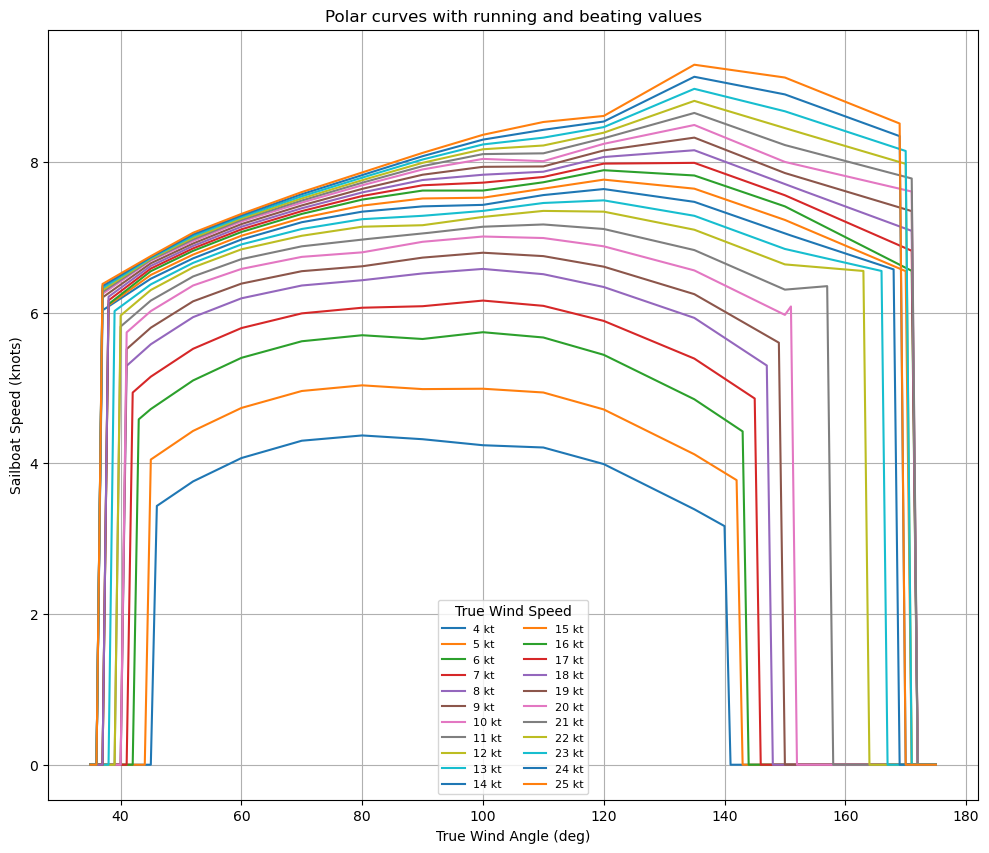

In [67]:
## Plot polars curves with running and beating points

# Define ranges
TWA_range = np.arange(35, 176, 1)
TWS_range_knots = np.arange(4, 26, 1)

plt.figure(figsize=(12, 10))

for tws_knots in TWS_range_knots:
    TWS_ms = tws_knots * KNOT_TO_MS

    Vs_line = [
        compute_Vs(twa, TWS_ms, data) / KNOT_TO_MS  # convert to knots for plotting
        for twa in TWA_range
    ]

    plt.plot(TWA_range, Vs_line, label=f"{tws_knots} kt")

plt.xlabel("True Wind Angle (deg)")
plt.ylabel("Sailboat Speed (knots)")
plt.title("Polar curves with running and beating values")

plt.legend(title = "True Wind Speed", ncol=2, fontsize=8)
plt.grid(True)
plt.show()

In [68]:
# =========================================================
# GRID / VMG COST SURFACE (8 DIRECTIONS)
# =========================================================

NM_TO_M = 1852.0
CELL_SIZE_NM = 0.25
CELL_SIZE_M = CELL_SIZE_NM * NM_TO_M

SQRT2 = np.sqrt(2)

# 8 directions (degrees, nautical convention)
HEADINGS_8 = np.array([0, 45, 90, 135, 180, 225, 270, 315])


def compute_vmg(V_eff, heading, goal_dir):
    """
    Velocity Made Good toward goal direction.
    """
    angle = np.radians(heading - goal_dir)
    return V_eff * np.cos(angle)


def cell_distance(heading):
    """
    Distance traveled in one grid step.
    """
    if heading % 90 == 0:
        return CELL_SIZE_M
    else:
        return CELL_SIZE_M * SQRT2


def compute_vmg_cost_surface_cell(
    TWA,
    TWS,
    Hs,
    T,
    wave_dir,
    depth,
    draft,
    compute_Vs,
    data,
    boat_heading,
    goal_dir
):
    """
    Returns:
        cost_per_direction[8],
        vmg_per_direction[8],
        V_eff_used (for diagnostics)
    """

    costs = np.zeros(len(HEADINGS_8))
    vmgs = np.zeros(len(HEADINGS_8))

    # compute wave-adjusted speed once per heading
    for i, hdg in enumerate(HEADINGS_8):

        V_eff, diag = sailboat_speed_single_cell(
            TWA=TWA,
            TWS=TWS,
            Hs=Hs,
            T=T,
            wave_dir=wave_dir,
            depth=depth,
            draft=draft,
            compute_Vs=compute_Vs,
            data=data,
            boat_heading=hdg
        )

        if np.isnan(V_eff) or V_eff <= 0:
            costs[i] = np.inf
            vmgs[i] = -np.inf
            continue

        # VMG toward goal
        vmg = compute_vmg(V_eff, hdg, goal_dir)
        vmgs[i] = vmg

        # infeasible direction (sailing away or no progress)
        if vmg <= 0:
            costs[i] = np.inf
            continue

        # time to cross cell (IMPORTANT STEP)
        d = cell_distance(hdg)
        costs[i] = d / vmg

    # =========================
    # DEBUG PRINT BLOCK 
    # =========================
    print("Direction diagnostics:")
    print("Dir | VMG | feasible | cost")
    for i in range(8):
        feasible = np.isfinite(costs[i])
        print(i, vmgs[i], feasible, costs[i])

    return costs, vmgs


In [ ]:
# =========================================================
# EXAMPLE USAGE
# =========================================================

goal_dir = 100  # direction toward final destination from this cell

costs, vmgs = compute_vmg_cost_surface_cell(
    TWA=TWA_input,
    TWS=TWS_input_ms,
    Hs=wave_height,
    T=wave_period,
    wave_dir=wave_dir,
    depth=depth,
    draft=draft,
    compute_Vs=compute_Vs,
    data=data,
    boat_heading=boat_heading,
    goal_dir=goal_dir
)

print("VMG values:", vmgs)
print("Costs (seconds per direction):", costs)



Direction diagnostics:
Dir | VMG | feasible | cost
0 -0.7056464572632094 False inf
1 2.330835037733334 True 280.92115863141373
2 4.002016862687773 True 115.69166644866336
3 3.3288805381705138 True 196.69701927441275
4 0.7056774468064124 True 656.1071238642181
5 -2.3309072466265897 False inf
6 -4.002016862687773 False inf
7 -3.328777413183542 False inf
VMG values: [-0.70564646  2.33083504  4.00201686  3.32888054  0.70567745 -2.33090725
 -4.00201686 -3.32877741]
Costs (seconds per direction): [         inf 280.92115863 115.69166645 196.69701927 656.10712386
          inf          inf          inf]
